# Customer Lifecycle and Revenue Intelligence System
## Stage 1: Data Preprocessing and Exploratory Data Analysis

**Dataset:** Online Retail II (UCI Machine Learning Repository) <br>
**Period:** December 2009 to December 2011 <br>
**Goal:** Merge, clean, validate, engineer features, and export three analytical tables for the SQL layer.

---
### Pipeline Overview
1. Load both Excel sheets and merge into a unified dataset  
2. Conduct initial exploratory scan (shape, types, nulls, duplicates)  
3. Identify and remove data quality issues step by step  
4. Engineer analytical features  
5. Build and export three structured tables: `transactions`, `orders`, `customers`  
6. Generate a cohort retention heatmap for documentation  

---

## 0. Environment Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

# PATH CONFIGURATION
BASE_DIR   = Path(r"C:\Users\ASUS\Projects\Portfolio - Customer Lifecycle and Revenue Intelligence System")
RAW_FILE   = BASE_DIR / "online_retail_II.xlsx"
DATA_DIR   = BASE_DIR / "data"
OUTPUT_DIR = BASE_DIR / "outputs"

DATA_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Libraries loaded.")
print(f"Project root : {BASE_DIR}")
print(f"Raw file     : {RAW_FILE}")
print(f"File exists  : {RAW_FILE.exists()}")

Libraries loaded.
Project root : C:\Users\ASUS\Projects\Portfolio - Customer Lifecycle and Revenue Intelligence System
Raw file     : C:\Users\ASUS\Projects\Portfolio - Customer Lifecycle and Revenue Intelligence System\online_retail_II.xlsx
File exists  : True


---
## 1. Load Raw Data

In [2]:
# Load both sheets. We pass dtype={'Customer ID': str} to prevent
# pandas from reading the numeric-looking ID as a float, which would
# produce trailing '.0' in the values.

print("Year 2009-2010")
df_0910 = pd.read_excel(RAW_FILE, sheet_name="Year 2009-2010", dtype={"Customer ID": str})
print(f"  Rows: {len(df_0910):,}   Columns: {df_0910.shape[1]}")

print("Year 2010-2011")
df_1011 = pd.read_excel(RAW_FILE, sheet_name="Year 2010-2011", dtype={"Customer ID": str})
print(f"  Rows: {len(df_1011):,}   Columns: {df_1011.shape[1]}")

# Tag the source sheet for traceability before merging
df_0910["source_sheet"] = "2009-2010"
df_1011["source_sheet"] = "2010-2011"

# Merge into one unified DataFrame
df_raw = pd.concat([df_0910, df_1011], ignore_index=True)
print(f"\nCombined rows: {len(df_raw):,}")

Year 2009-2010
  Rows: 525,461   Columns: 8
Year 2010-2011
  Rows: 541,910   Columns: 8

Combined rows: 1,067,371


In [3]:
# Preview the first five rows of the merged dataset
df_raw.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,source_sheet
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,2009-2010
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,2009-2010
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,2009-2010
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,2009-2010
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,2009-2010


---
## 2. Column Standardization

In [4]:
# Rename columns to snake_case for SQL and Python consistency.
# The original column names include spaces and mixed case.

df_raw.rename(columns={
    "Invoice"      : "invoice",
    "StockCode"    : "stock_code",
    "Description"  : "description",
    "Quantity"     : "quantity",
    "InvoiceDate"  : "invoice_date",
    "Price"        : "price",
    "Customer ID"  : "customer_id",
    "Country"      : "country",
    "source_sheet" : "source_sheet",
}, inplace=True)

print("Column names standardized:")
print(list(df_raw.columns))

Column names standardized:
['invoice', 'stock_code', 'description', 'quantity', 'invoice_date', 'price', 'customer_id', 'country', 'source_sheet']


---
## 3. Initial Exploratory Scan
Documenting the state of the raw data before removing anything. This part preserves a clear audit trail.

In [5]:
# 3.1 Shape and data types 

print(f"Shape: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns")
print("\nData types:")
print(df_raw.dtypes)

Shape: 1,067,371 rows x 9 columns

Data types:
invoice                 object
stock_code              object
description             object
quantity                 int64
invoice_date    datetime64[ns]
price                  float64
customer_id             object
country                 object
source_sheet            object
dtype: object


In [6]:
# 3.2 Missing value audit 
# Count and percentage of nulls per column

null_counts = df_raw.isnull().sum()
null_pct    = (null_counts / len(df_raw) * 100).round(2)
null_audit  = pd.DataFrame({"null_count": null_counts, "null_pct": null_pct})
null_audit  = null_audit[null_audit["null_count"] > 0]
print("Columns with missing values:")
print(null_audit.to_string())

Columns with missing values:
             null_count  null_pct
description        4382      0.41
customer_id      243007     22.77


In [7]:
# 3.3 Duplicate row check

n_dupes = df_raw.duplicated().sum()
print(f"Fully duplicated rows: {n_dupes:,}")

Fully duplicated rows: 12,133


In [8]:
# 3.4 Cancellation identification

# Invoice numbers beginning with 'C' are cancellations.
is_cancelled = df_raw["invoice"].astype(str).str.upper().str.startswith("C")
print(f"Cancellation records (invoice starts with 'C'): {is_cancelled.sum():,}")

# Preview a few cancellation records
df_raw[is_cancelled][["invoice", "customer_id", "quantity", "price"]].head()

Cancellation records (invoice starts with 'C'): 19,494


,invoice,customer_id,quantity,price
178,C489449,16321,-12,2.95
179,C489449,16321,-6,1.65
180,C489449,16321,-4,4.25
181,C489449,16321,-6,2.10
182,C489449,16321,-12,2.95


In [9]:
# 3.5 Numerical anomaly scan

print("Quantity distribution:")
print(df_raw["quantity"].describe())
print(f"\nRows with quantity <= 0 : {(df_raw['quantity'] <= 0).sum():,}")

print("\nPrice distribution:")
print(df_raw["price"].describe())
print(f"Rows with price <= 0    : {(df_raw['price'] <= 0).sum():,}")

Quantity distribution:
count   1,067,371.00
mean            9.94
std           172.71
min       -80,995.00
25%             1.00
50%             3.00
75%            10.00
max        80,995.00
Name: quantity, dtype: float64

Rows with quantity <= 0 : 22,950

Price distribution:
count   1,067,371.00
mean            4.65
std           123.55
min       -53,594.36
25%             1.25
50%             2.10
75%             4.15
max        38,970.00
Name: price, dtype: float64
Rows with price <= 0    : 6,207


In [10]:
# 3.6 Non-product stock code identification
# Certain stock codes represent internal charges (postage, bank fees, manual adjustments) that are not sellable products.

NON_PRODUCT_CODES = {"POST", "D", "C2", "M", "BANK CHARGES", "PADS", "DOT", "CRUK", "S", "ADJUST"}
is_non_product = df_raw["stock_code"].astype(str).str.upper().str.strip().isin(NON_PRODUCT_CODES)
print(f"Non-product stock code records: {is_non_product.sum():,}")
print(df_raw[is_non_product][["stock_code", "description", "price"]].drop_duplicates().to_string())

Non-product stock code records: 5,761
           stock_code                          description     price
89               POST                              POSTAGE     18.00
126              POST                              POSTAGE    141.00
173              POST                              POSTAGE    130.00
735                 D                             Discount      9.00
736                 D                             Discount     19.00
927              POST                              POSTAGE      9.58
2379              DOT                       DOTCOM POSTAGE    647.19
2539              DOT                       DOTCOM POSTAGE     55.96
2551              DOT                       DOTCOM POSTAGE     68.39
2571              DOT                       DOTCOM POSTAGE     59.35
2619              DOT                       DOTCOM POSTAGE     42.39
2644              DOT                       DOTCOM POSTAGE     50.87
2686              DOT                       DOTCOM POSTAGE     76

In [11]:
# 3.7 Country distribution in raw data

country_counts = df_raw["country"].value_counts()
print(f"Unique countries: {df_raw['country'].nunique()}")
print("\nTop 10 countries by transaction count:")
print(country_counts.head(10).to_string())

Unique countries: 43

Top 10 countries by transaction count:
country
United Kingdom    981330
EIRE               17866
Germany            17624
France             14330
Netherlands         5140
Spain               3811
Switzerland         3189
Belgium             3123
Portugal            2620
Australia           1913


---
## 4. Systematic Cleaning Pipeline
Each filter is applied sequentially. After each step, the row count is printed to show the exact impact.

In [13]:
df = df_raw.copy()
log = []   # Stores cleaning log entries for the final summary

def log_filter(label, n_before, n_after):
    removed = n_before - n_after
    pct     = 100 * removed / n_before if n_before > 0 else 0
    log.append({"step": label, "rows_after": n_after, "removed": removed, "removed_pct": round(pct, 2)})
    print(f"  {label:<45} {n_after:>9,}  removed: {removed:>7,}  ({pct:.1f}%)")

n0 = len(df)

print(f"{'Step':<45} {'Rows After':>10}  {'Removed':>16}")
print(f"  {'Raw combined dataset':<43} {n0:>9,}")

Step                                          Rows After           Removed
  Raw combined dataset                        1,067,371


In [14]:
# Step 4.1: Remove exact duplicate rows

n_before = len(df)
df = df.drop_duplicates()
log_filter("Remove fully duplicated rows", n_before, len(df))

  Remove fully duplicated rows                  1,055,238  removed:  12,133  (1.1%)


In [15]:
# Step 4.2: Remove cancelled transactions
# Invoice codes starting with 'C' indicate returns or cancellations.
# These records should not appear in revenue or lifecycle calculations.

n_before = len(df)
df = df[~df["invoice"].astype(str).str.upper().str.startswith("C")]
log_filter("Remove cancellations (invoice prefix 'C')", n_before, len(df))

  Remove cancellations (invoice prefix 'C')     1,035,805  removed:  19,433  (1.8%)


In [16]:
# Step 4.3: Remove rows with missing customer_id ---
# Rows without a customer identifier cannot contribute to any
# customer-level metric: cohort retention, RFM scoring, or LTV.

n_before = len(df)
df["customer_id"] = df["customer_id"].astype(str).str.strip()
df = df[~df["customer_id"].isin(["", "nan", "NaN", "None"])]
log_filter("Remove missing customer_id", n_before, len(df))

  Remove missing customer_id                      793,680  removed: 242,125  (23.4%)


In [17]:
# Step 4.4: Remove non-positive quantities
# Zero or negative quantities are not valid sales records.
# Negative quantities outside of cancellation invoices may indicate
# data entry errors.

n_before = len(df)
df = df[df["quantity"] > 0]
log_filter("Remove quantity <= 0", n_before, len(df))

  Remove quantity <= 0                            793,680  removed:       0  (0.0%)


In [18]:
# Step 4.5: Remove non-positive unit prices
# A zero price may indicate a promotional or test record.
# Negative prices have no commercial interpretation.

n_before = len(df)
df = df[df["price"] > 0]
log_filter("Remove price <= 0", n_before, len(df))

  Remove price <= 0                               793,609  removed:      71  (0.0%)


In [19]:
# Step 4.6: Remove non-product stock codes

n_before = len(df)
df = df[~df["stock_code"].astype(str).str.upper().str.strip().isin(NON_PRODUCT_CODES)]
log_filter("Remove non-product stock codes", n_before, len(df))

  Remove non-product stock codes                  790,717  removed:   2,892  (0.4%)


In [21]:
# Cleaning Log Summary

print("\nCleaning Summary:")
print(f"  {'Step':<45} {'Rows After':>10}  {'Removed':>8}")

for entry in log:
    print(f"  {entry['step']:<45} {entry['rows_after']:>10,}  {entry['removed']:>8,}")

print("")
print(f"  Total removed from {n0:,} raw rows: {n0 - len(df):,} ({100*(n0-len(df))/n0:.1f}%)")
print(f"  Final clean dataset: {len(df):,} rows")


Cleaning Summary:
  Step                                          Rows After   Removed
  Remove fully duplicated rows                   1,055,238    12,133
  Remove cancellations (invoice prefix 'C')      1,035,805    19,433
  Remove missing customer_id                       793,680   242,125
  Remove quantity <= 0                             793,680         0
  Remove price <= 0                                793,609        71
  Remove non-product stock codes                   790,717     2,892

  Total removed from 1,067,371 raw rows: 276,654 (25.9%)
  Final clean dataset: 790,717 rows


---
## 5. Feature Engineering

In [22]:
# 5.1 Parse datetime
df["invoice_date"] = pd.to_datetime(df["invoice_date"])

# 5.2 Time-based features
df["invoice_date_only"] = df["invoice_date"].dt.date.astype(str)
df["invoice_year"]      = df["invoice_date"].dt.year
df["invoice_month"]     = df["invoice_date"].dt.month
df["invoice_yearmonth"] = df["invoice_date"].dt.to_period("M").astype(str)
df["day_of_week"]       = df["invoice_date"].dt.day_name()

# 5.3 Revenue (core financial metric) 
# Each row represents one line item within an invoice.
# Revenue = quantity purchased * unit price.
df["revenue"] = (df["quantity"] * df["price"]).round(2)

print("New features added:")
print(["invoice_date_only", "invoice_year", "invoice_month",
       "invoice_yearmonth", "day_of_week", "revenue"])
print(f"\nRevenue range: £{df['revenue'].min():,.2f} to £{df['revenue'].max():,.2f}")
print(f"Total revenue: £{df['revenue'].sum():,.2f}")

New features added:
['invoice_date_only', 'invoice_year', 'invoice_month', 'invoice_yearmonth', 'day_of_week', 'revenue']

Revenue range: £0.06 to £168,469.60
Total revenue: £17,377,841.89


In [23]:
# 5.4 Define canonical column order for the transactions table ---
df = df[[
    "invoice", "stock_code", "description",
    "quantity", "price", "revenue",
    "invoice_date", "invoice_date_only",
    "invoice_year", "invoice_month", "invoice_yearmonth", "day_of_week",
    "customer_id", "country"
]]

print("Final column order:")
print(list(df.columns))
print(f"\nShape: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head(3)

Final column order:
['invoice', 'stock_code', 'description', 'quantity', 'price', 'revenue', 'invoice_date', 'invoice_date_only', 'invoice_year', 'invoice_month', 'invoice_yearmonth', 'day_of_week', 'customer_id', 'country']

Shape: 790,717 rows x 14 columns


,invoice,stock_code,description,quantity,price,revenue,invoice_date,invoice_date_only,invoice_year,invoice_month,invoice_yearmonth,day_of_week,customer_id,country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,6.95,83.40,2009-12-01 07:45:00,2009-12-01,2009,12,2009-12,Tuesday,13085,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,6.75,81.00,2009-12-01 07:45:00,2009-12-01,2009,12,2009-12,Tuesday,13085,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,6.75,81.00,2009-12-01 07:45:00,2009-12-01,2009,12,2009-12,Tuesday,13085,United Kingdom


---
## 6. Post-Cleaning Validation

In [24]:
print("Post-Cleaning Data Profile\n")

print(f"  Rows (line items)   : {len(df):>10,}")
print(f"  Unique invoices     : {df['invoice'].nunique():>10,}")
print(f"  Unique customers    : {df['customer_id'].nunique():>10,}")
print(f"  Unique products     : {df['stock_code'].nunique():>10,}")
print(f"  Unique countries    : {df['country'].nunique():>10,}")
print(f"  Date range          : {df['invoice_date'].min().date()} to {df['invoice_date'].max().date()}")
print(f"  Total revenue       : £{df['revenue'].sum():>12,.2f}")
print(f"  Avg line revenue    : £{df['revenue'].mean():>12.2f}")
print(f"  Remaining nulls     : {df.isnull().sum().sum()}")

Post-Cleaning Data Profile

  Rows (line items)   :    790,717
  Unique invoices     :     36,607
  Unique customers    :      5,852
  Unique products     :      4,623
  Unique countries    :         41
  Date range          : 2009-12-01 to 2011-12-09
  Total revenue       : £17,377,841.89
  Avg line revenue    : £       21.98
  Remaining nulls     : 0


In [25]:
# Confirm no nulls remain in any business-critical column

critical_cols = ["invoice", "stock_code", "quantity", "price", "revenue",
                 "invoice_date", "customer_id", "country"]
null_check = df[critical_cols].isnull().sum()
print("Null check on critical columns:")
print(null_check.to_string())
print("\nAll critical columns are null-free:", (null_check == 0).all())

Null check on critical columns:
invoice         0
stock_code      0
quantity        0
price           0
revenue         0
invoice_date    0
customer_id     0
country         0

All critical columns are null-free: True


---
## 7. Build Three Analytical Tables

In [26]:
# TABLE 1: TRANSACTIONS
# One row per invoice line item. This is the cleaned base table.

transactions = df.copy()

print(f"transactions table: {len(transactions):,} rows")
transactions.head(3)

transactions table: 790,717 rows


,invoice,stock_code,description,quantity,price,revenue,invoice_date,invoice_date_only,invoice_year,invoice_month,invoice_yearmonth,day_of_week,customer_id,country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,6.95,83.40,2009-12-01 07:45:00,2009-12-01,2009,12,2009-12,Tuesday,13085,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,6.75,81.00,2009-12-01 07:45:00,2009-12-01,2009,12,2009-12,Tuesday,13085,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,6.75,81.00,2009-12-01 07:45:00,2009-12-01,2009,12,2009-12,Tuesday,13085,United Kingdom


In [27]:
# TABLE 2: ORDERS
# One row per invoice. Aggregates line items to invoice level.

orders = (
    df.groupby(
        ["invoice", "customer_id", "country",
         "invoice_date_only", "invoice_yearmonth",
         "invoice_year", "invoice_month", "day_of_week"]
    )
    .agg(
        invoice_date      = ("invoice_date",  "min"),
        line_item_count   = ("stock_code",    "count"),
        distinct_products = ("stock_code",    "nunique"),
        total_quantity    = ("quantity",       "sum"),
        order_revenue     = ("revenue",        "sum"),
    )
    .reset_index()
)
orders["order_revenue"] = orders["order_revenue"].round(2)

# Column order
orders = orders[[
    "invoice", "customer_id", "country",
    "invoice_date", "invoice_date_only",
    "invoice_year", "invoice_month", "invoice_yearmonth", "day_of_week",
    "line_item_count", "distinct_products", "total_quantity", "order_revenue"
]]

print(f"orders table: {len(orders):,} rows")
orders.head(3)

orders table: 36,607 rows


,invoice,customer_id,country,invoice_date,invoice_date_only,invoice_year,invoice_month,invoice_yearmonth,day_of_week,line_item_count,distinct_products,total_quantity,order_revenue
0,489434,13085,United Kingdom,2009-12-01 07:45:00,2009-12-01,2009,12,2009-12,Tuesday,8,8,166,505.30
1,489435,13085,United Kingdom,2009-12-01 07:46:00,2009-12-01,2009,12,2009-12,Tuesday,4,4,60,145.80
2,489436,13078,United Kingdom,2009-12-01 09:06:00,2009-12-01,2009,12,2009-12,Tuesday,19,19,193,630.33


In [28]:
# TABLE 3: CUSTOMERS
# One row per customer. Lifetime behavioral summary.
# The reference_date is set to one day after the last transaction,
# making recency_days a meaningful staleness measure.

REFERENCE_DATE = pd.Timestamp("2011-12-10")

customers = (
    df.groupby(["customer_id", "country"])
    .agg(
        first_purchase_date = ("invoice_date", "min"),
        last_purchase_date  = ("invoice_date", "max"),
        total_orders        = ("invoice",       "nunique"),
        active_months       = ("invoice_yearmonth", "nunique"),
        total_products      = ("stock_code",    "nunique"),
        total_quantity      = ("quantity",       "sum"),
        lifetime_revenue    = ("revenue",        "sum"),
    )
    .reset_index()
)

customers["lifetime_revenue"] = customers["lifetime_revenue"].round(2)
customers["avg_order_value"]  = (customers["lifetime_revenue"] / customers["total_orders"]).round(2)
customers["recency_days"]     = (REFERENCE_DATE - customers["last_purchase_date"]).dt.days
customers["first_purchase_date"] = customers["first_purchase_date"].dt.date.astype(str)
customers["last_purchase_date"]  = customers["last_purchase_date"].dt.date.astype(str)

# Column order
customers = customers[[
    "customer_id", "country",
    "first_purchase_date", "last_purchase_date",
    "total_orders", "active_months", "total_products",
    "total_quantity", "lifetime_revenue", "avg_order_value", "recency_days"
]]

print(f"customers table: {len(customers):,} rows")
customers.head(3)

customers table: 5,864 rows


,customer_id,country,first_purchase_date,last_purchase_date,total_orders,active_months,total_products,total_quantity,lifetime_revenue,avg_order_value,recency_days
0,12346,United Kingdom,2009-12-14,2011-01-18,12,5,27,74285,"77,556.46","6,463.04",325
1,12347,Iceland,2010-10-31,2011-12-07,8,8,126,3286,"5,633.32",704.16,2
2,12348,Finland,2010-09-27,2011-09-25,5,5,24,2704,"1,658.40",331.68,75


In [29]:
# Quick sanity checks across the three tables

print("Sanity checks:")
print(f"  transactions revenue sum : £{transactions['revenue'].sum():>12,.2f}")
print(f"  orders revenue sum       : £{orders['order_revenue'].sum():>12,.2f}")
print(f"  customers revenue sum    : £{customers['lifetime_revenue'].sum():>12,.2f}")
print(f"  All three match          : {abs(transactions['revenue'].sum() - customers['lifetime_revenue'].sum()) < 1}")

Sanity checks:
  transactions revenue sum : £17,377,841.89
  orders revenue sum       : £17,377,841.89
  customers revenue sum    : £17,377,841.89
  All three match          : True


---
## 8. Exploratory Visualizations

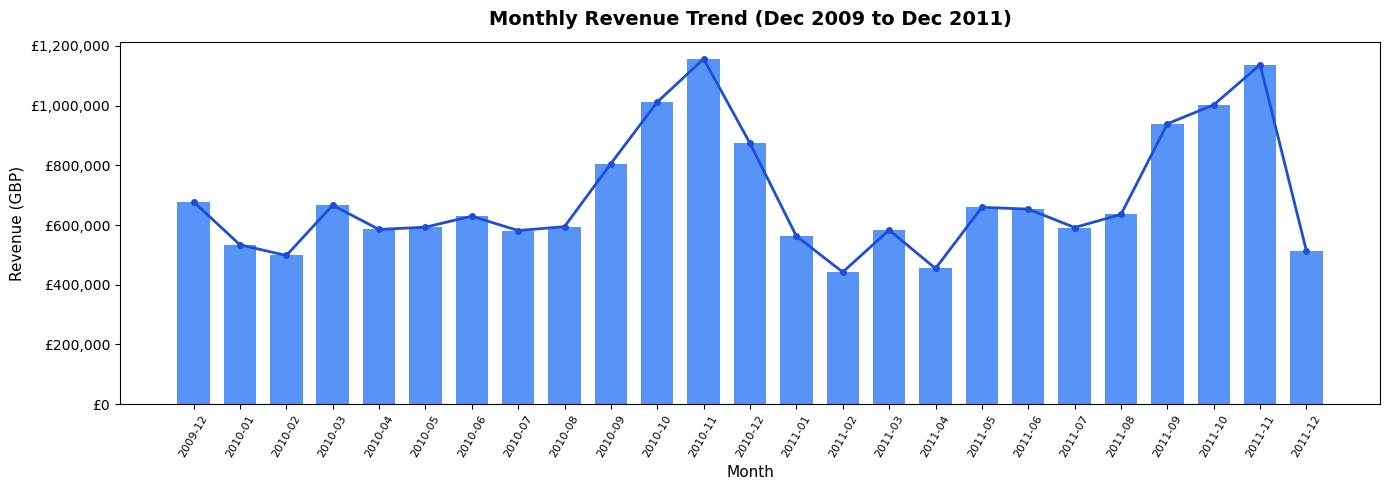

Saved: monthly_revenue_trend.png


In [30]:
# 8.1 Monthly Revenue Trend

monthly_rev = (
    transactions
    .groupby("invoice_yearmonth")["revenue"]
    .sum()
    .reset_index()
    .sort_values("invoice_yearmonth")
)

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(monthly_rev["invoice_yearmonth"], monthly_rev["revenue"],
       color="#3B82F6", alpha=0.85, width=0.7)
ax.plot(monthly_rev["invoice_yearmonth"], monthly_rev["revenue"],
        color="#1D4ED8", linewidth=2, marker="o", markersize=4)
ax.set_title("Monthly Revenue Trend (Dec 2009 to Dec 2011)",
             fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("Month", fontsize=11)
ax.set_ylabel("Revenue (GBP)", fontsize=11)
ax.tick_params(axis="x", rotation=60, labelsize=8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"£{x:,.0f}"))
fig.tight_layout()
plt.savefig(OUTPUT_DIR / "monthly_revenue_trend.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: monthly_revenue_trend.png")

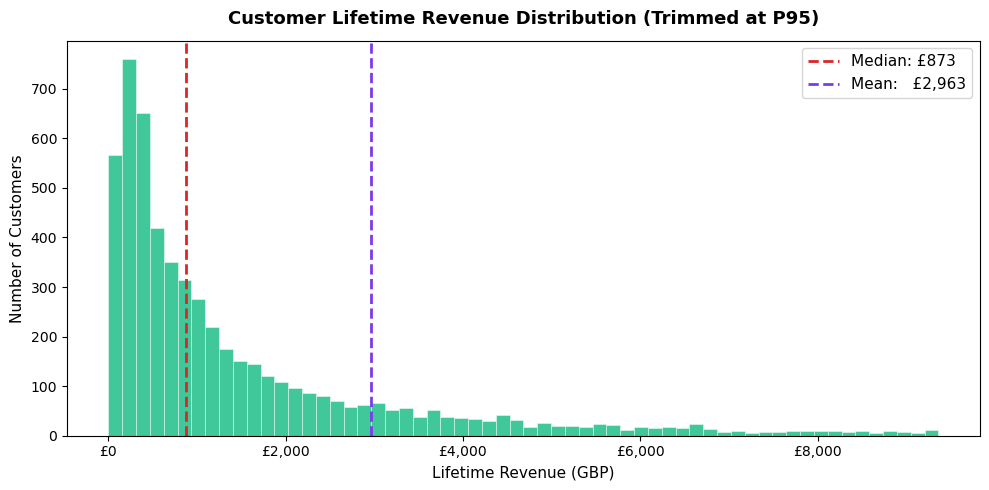

Saved: ltv_distribution.png


In [31]:
# 8.2 Customer Lifetime Value Distribution
# Trim the right tail to 95th percentile for visual clarity

ltv_cap = customers["lifetime_revenue"].quantile(0.95)
ltv_trim = customers[customers["lifetime_revenue"] <= ltv_cap]["lifetime_revenue"]

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(ltv_trim, bins=60, color="#10B981", alpha=0.8, edgecolor="white", linewidth=0.4)
ax.axvline(customers["lifetime_revenue"].median(), color="#DC2626",
           linestyle="--", linewidth=2, label=f"Median: £{customers['lifetime_revenue'].median():,.0f}")
ax.axvline(customers["lifetime_revenue"].mean(), color="#7C3AED",
           linestyle="--", linewidth=2, label=f"Mean:   £{customers['lifetime_revenue'].mean():,.0f}")
ax.set_title("Customer Lifetime Revenue Distribution (Trimmed at P95)",
             fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("Lifetime Revenue (GBP)", fontsize=11)
ax.set_ylabel("Number of Customers", fontsize=11)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"£{x:,.0f}"))
ax.legend(fontsize=11)
fig.tight_layout()
plt.savefig(OUTPUT_DIR / "ltv_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: ltv_distribution.png")

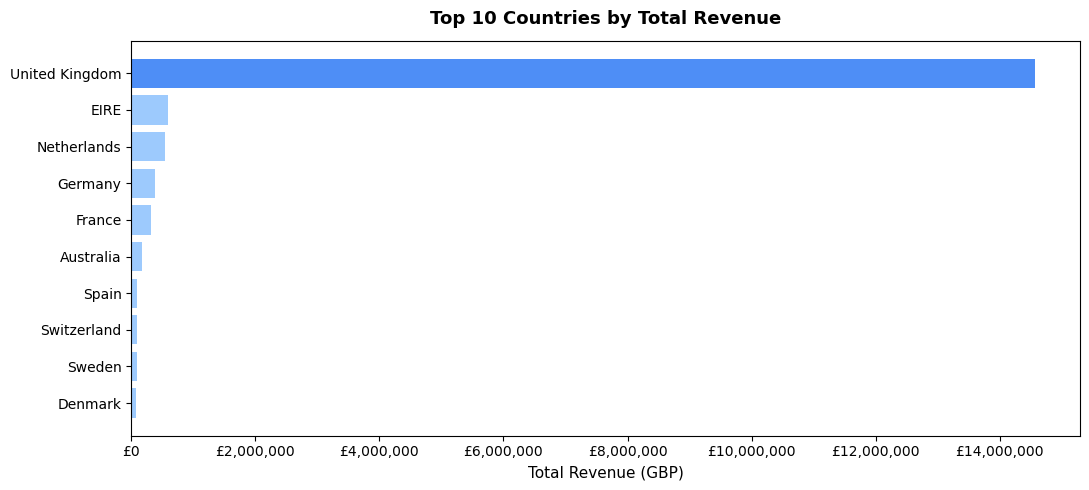

Saved: top_countries_revenue.png


In [32]:
# 8.3 Top 10 Countries by Revenue

country_rev = (
    transactions
    .groupby("country")["revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

colors = ["#3B82F6" if c == "United Kingdom" else "#93C5FD" for c in country_rev["country"]]

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(country_rev["country"][::-1], country_rev["revenue"][::-1],
               color=colors[::-1], alpha=0.9)
ax.set_title("Top 10 Countries by Total Revenue",
             fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("Total Revenue (GBP)", fontsize=11)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"£{x:,.0f}"))
fig.tight_layout()
plt.savefig(OUTPUT_DIR / "top_countries_revenue.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: top_countries_revenue.png")

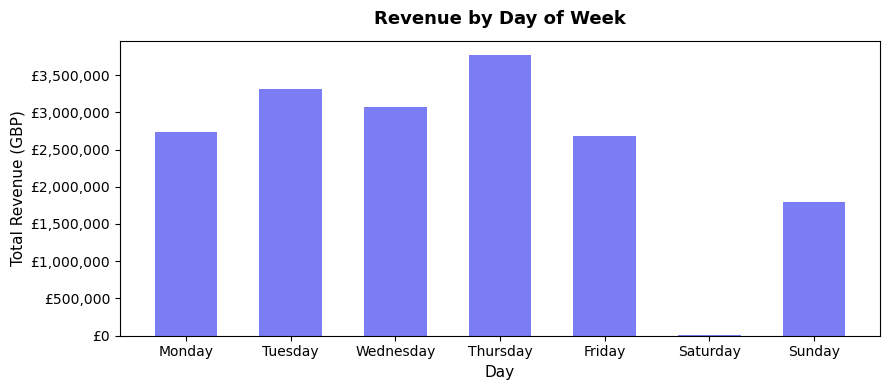

Saved: revenue_by_day_of_week.png


In [33]:
# 8.4 Revenue by Day of Week

day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
day_rev = (
    transactions
    .groupby("day_of_week")["revenue"]
    .sum()
    .reindex(day_order)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(day_rev["day_of_week"], day_rev["revenue"],
       color="#6366F1", alpha=0.85, width=0.6)
ax.set_title("Revenue by Day of Week", fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("Day", fontsize=11)
ax.set_ylabel("Total Revenue (GBP)", fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"£{x:,.0f}"))
fig.tight_layout()
plt.savefig(OUTPUT_DIR / "revenue_by_day_of_week.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: revenue_by_day_of_week.png")

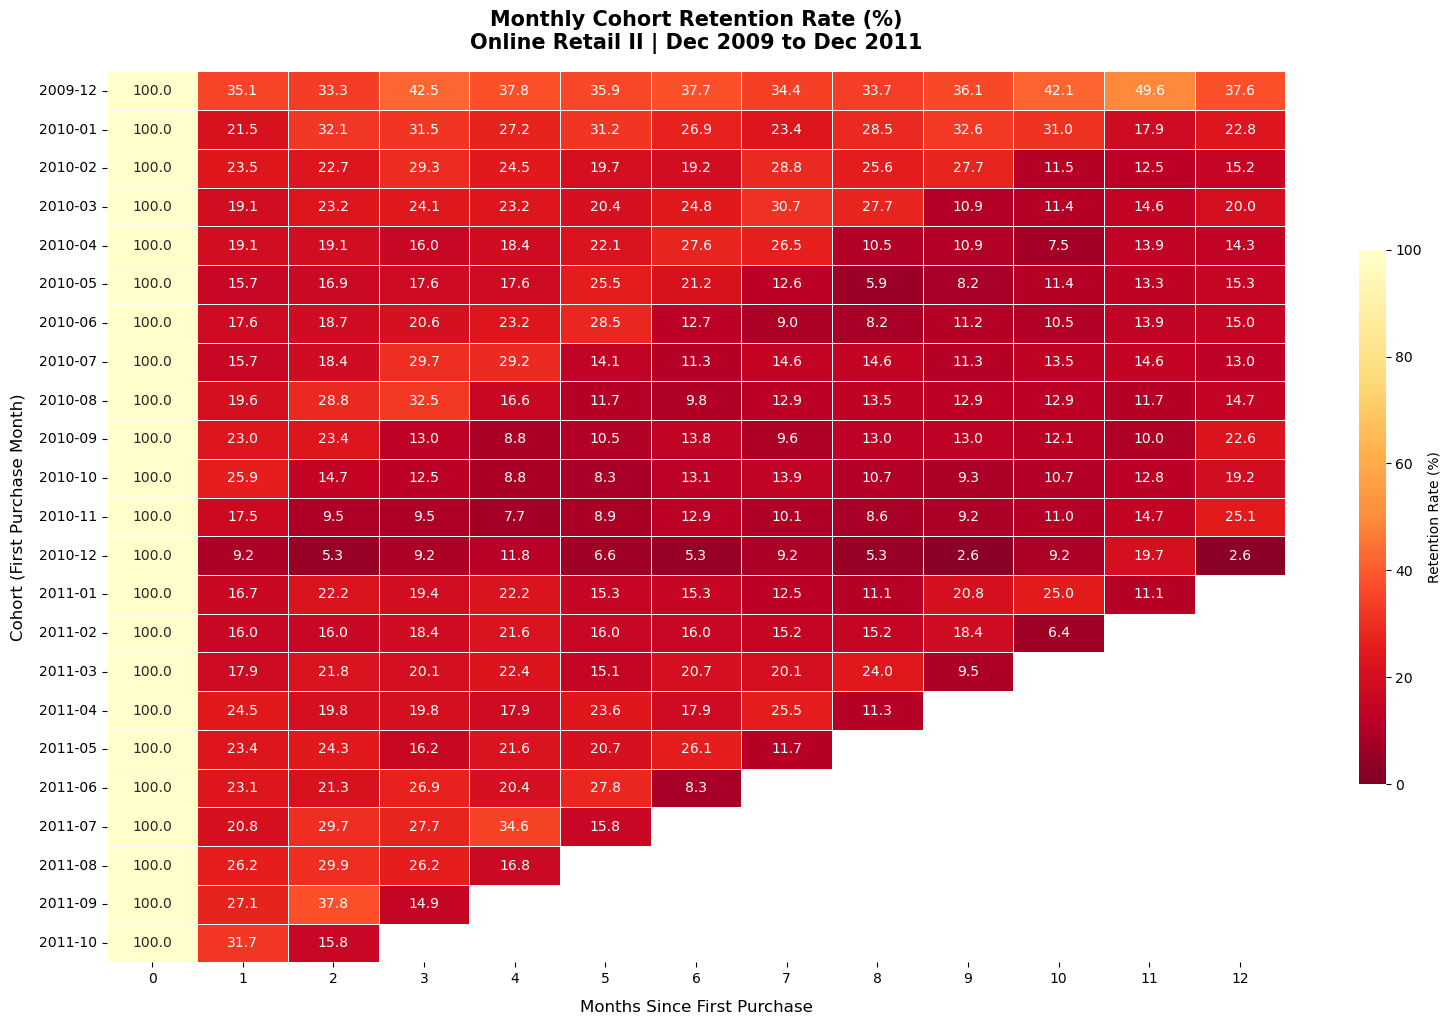

Saved: cohort_retention_heatmap.png


In [34]:
# 8.5 Cohort Retention Heatmap
# Assign each customer their first purchase month (cohort)

first_purchase = (
    transactions.groupby("customer_id")["invoice_yearmonth"]
    .min()
    .rename("cohort_month")
    .reset_index()
)

df_cohort = transactions.merge(first_purchase, on="customer_id")

# Convert periods to datetime for month arithmetic
df_cohort["cohort_dt"]   = pd.to_datetime(df_cohort["cohort_month"])
df_cohort["activity_dt"] = pd.to_datetime(df_cohort["invoice_yearmonth"])
df_cohort["month_number"] = (
    (df_cohort["activity_dt"].dt.year  - df_cohort["cohort_dt"].dt.year) * 12
  + (df_cohort["activity_dt"].dt.month - df_cohort["cohort_dt"].dt.month)
)

# Count distinct active customers per cohort per month
cohort_data = (
    df_cohort.groupby(["cohort_month", "month_number"])["customer_id"]
    .nunique()
    .reset_index(name="active_customers")
)

# Cohort sizes (month 0 = full cohort)
cohort_sizes = cohort_data[cohort_data["month_number"] == 0].set_index("cohort_month")["active_customers"]
cohort_data["cohort_size"]      = cohort_data["cohort_month"].map(cohort_sizes)
cohort_data["retention_rate"]   = (cohort_data["active_customers"] / cohort_data["cohort_size"] * 100).round(2)

# Pivot into matrix
pivot = cohort_data.pivot_table(
    index="cohort_month", columns="month_number", values="retention_rate"
)
pivot = pivot[[c for c in pivot.columns if c < 13]]   # Months 0-12
pivot = pivot[pivot.count(axis=1) >= 3]                # Remove stub cohorts

fig, ax = plt.subplots(figsize=(16, max(8, len(pivot) * 0.45)))
sns.heatmap(
    pivot, annot=True, fmt=".1f", cmap="YlOrRd_r",
    linewidths=0.4, linecolor="white",
    vmin=0, vmax=100,
    cbar_kws={"label": "Retention Rate (%)", "shrink": 0.6},
    ax=ax,
)
ax.set_title(
    "Monthly Cohort Retention Rate (%)\nOnline Retail II | Dec 2009 to Dec 2011",
    fontsize=15, fontweight="bold", pad=16
)
ax.set_xlabel("Months Since First Purchase", fontsize=12, labelpad=10)
ax.set_ylabel("Cohort (First Purchase Month)", fontsize=12, labelpad=10)
ax.tick_params(axis="y", rotation=0)
fig.tight_layout()
plt.savefig(OUTPUT_DIR / "cohort_retention_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: cohort_retention_heatmap.png")

---
## 9. Export CSV Files for SQL Stage

In [35]:
# Convert invoice_date to string so it survives CSV round-trips cleanly.
# SQLite will read it as TEXT and we will parse it in queries.
transactions_export = transactions.copy()
transactions_export["invoice_date"] = transactions_export["invoice_date"].dt.strftime("%Y-%m-%d %H:%M:%S")

orders_export = orders.copy()
orders_export["invoice_date"] = orders_export["invoice_date"].dt.strftime("%Y-%m-%d %H:%M:%S")

# Export
transactions_export.to_csv(DATA_DIR / "transactions.csv", index=False)
orders_export.to_csv(DATA_DIR / "orders.csv",       index=False)
customers.to_csv(DATA_DIR / "customers.csv",         index=False)

# Also export the cohort retention table for direct use if needed
cohort_data.to_csv(DATA_DIR / "cohort_retention_python.csv", index=False)

print("Exported files to:", DATA_DIR)
for name in ["transactions.csv", "orders.csv", "customers.csv", "cohort_retention_python.csv"]:
    fp   = DATA_DIR / name
    size = fp.stat().st_size / 1024
    rows = pd.read_csv(fp).shape[0]
    print(f"  {name:<40} {rows:>8,} rows   {size:>7.1f} KB")

Exported files to: C:\Users\ASUS\Projects\Portfolio - Customer Lifecycle and Revenue Intelligence System\data
  transactions.csv                          790,717 rows   99598.0 KB
  orders.csv                                 36,607 rows    3521.1 KB
  customers.csv                               5,864 rows     415.2 KB
  cohort_retention_python.csv                   325 rows       7.7 KB


In [36]:
print("Stage 1 complete. Proceed to Beekeeper Studio for SQL analysis.")
print(f"Data directory: {DATA_DIR}")
print(f"  transactions.csv     (import as table 'transactions')")
print(f"  orders.csv           (import as table 'orders')")
print(f"  customers.csv        (import as table 'customers')")

Stage 1 complete. Proceed to Beekeeper Studio for SQL analysis.
Data directory: C:\Users\ASUS\Projects\Portfolio - Customer Lifecycle and Revenue Intelligence System\data
  transactions.csv     (import as table 'transactions')
  orders.csv           (import as table 'orders')
  customers.csv        (import as table 'customers')
